# Neural Networks: Forward Propagation

> 📖 Book: [ch08 – Artificial neural networks](../../.claude/skills/ml-knowledge/chapters/ch08-neural-networks.md) · Prev: [03_classification_metrics](../03_classification_metrics/01_confusion_matrix_precision_recall_f1.ipynb) · Next: backpropagation (to do, see [ROADMAP](../../notes/ROADMAP.md))

## Why neural networks?

Nonlinear boundaries with logistic regression need polynomial features, and those explode combinatorially: a degree-$k$ polynomial in $n$ variables has $\binom{n+k}{k} = O(n^k)$ terms. For a $100 \times 100$ image ($n = 10^4$ pixels), the quadratic terms alone are $\approx 5 \times 10^7$. An **artificial neural network (ANN)** instead *learns* its nonlinear features by stacking logistic units in layers.

**Forward propagation** is the computation an ANN performs on input data, given already-trained weights: the mathematical process that turns the input neurons into a prediction. There are many ways to design an ANN; let's start with some simple architectures.

## One input node, one hidden node, one output node

The simplest architecture: a single node in each layer.

![single node network](../../reports/figures/singlenode.png)

The hidden unit receives an attribute $x$ weighted by $\theta$, and the result goes through a nonlinear activation function (the "$a$" in the hidden node). Forward propagation:

1. Weight the input for the second layer:

    $$
    z^{(2)} = x\,\theta^{(1)} .
    $$

    The superscript $(2)$ says this intermediate value lives at the second layer.

2. Apply the activation, here the sigmoid:

    $$
    a^{(2)} = S(z^{(2)}) = \frac{1}{1 + e^{-z^{(2)}}} .
    $$

3. Weight the activation for the output layer:

    $$
    z^{(3)} = a^{(2)}\,\theta^{(2)} .
    $$

4. Compute the hypothesis:

    $$
    h_\theta(x) = a^{(3)} = S(z^{(3)}) = \frac{1}{1 + e^{-z^{(3)}}} .
    $$

The argument of each sigmoid is linear in both $\theta$ and $x$: each node is a simple one-feature regression.

## Several input nodes, one hidden node, one output node

![multi-input network](../../reports/figures/multinode01.png)

The simplest link between the input layer and the hidden node is the inner product of $x$ and $\theta$ (a linear regression); applying $S$ makes it a **logistic regression** of a linear function:

1. $z^{(2)} = x_0\theta_0^{(1)} + x_1\theta_1^{(1)} + \dots + x_n\theta_n^{(1)} = \sum_{i=0}^n x_i\theta_i^{(1)} = x^T\theta^{(1)}$ ($x$ is a column vector of features, hence the transpose);
2. $a^{(2)} = S(z^{(2)})$;
3. $z^{(3)} = a^{(2)}\theta^{(2)}$;
4. $h_\theta(x) = a^{(3)} = S(z^{(3)})$.

Remember to add the **bias node** $x_0 = 1$ in the input layer (the yellow node). Weights alone only change the steepness of the sigmoid; the bias *shifts* it. Without it the model is forced through the origin.

## Several input nodes, several hidden nodes, one output node

![multi-hidden network](../../reports/figures/multinode02.png)

Now we compute $p$ activation nodes $a_1^{(2)}, \dots, a_p^{(2)}$. Each hidden node $j$ takes the $n + 1$ inputs $x_i$ (including $x_0 = 1$) weighted by its own $\theta_{ij}^{(1)}$:

$$
z_j^{(2)} = \sum_{i=0}^n x_i\,\theta_{ij}^{(1)}, \qquad a_j^{(2)} = S(z_j^{(2)}) = \frac{1}{1 + e^{-z_j^{(2)}}}, \qquad j = 1, \dots, p .
$$

The weights form a matrix $\Theta^{(1)} \in \mathbb{R}^{(n+1)\times p}$: entry $\theta_{ij}^{(1)}$ connects input $i$ to hidden node $j$. Adding a bias node $a_0^{(2)} = 1$ to the hidden layer, the output is

$$
z^{(3)} = \sum_{j=0}^p a_j^{(2)}\theta_j^{(2)}, \qquad h_\theta(x) = a^{(3)} = S(z^{(3)}) .
$$

## Vectorized forward propagation

For $m$ samples at once, with $A^{(1)} = X$ ($m \times n$) and $\Theta^{(l)}$ of shape $(n_l + 1) \times n_{l+1}$:

$$
\boxed{A^{(l+1)} = S\left(\left[\mathbf{1},\, A^{(l)}\right]\Theta^{(l)}\right), \qquad l = 1, \dots, L, \qquad h_\Theta(X) = A^{(L+1)}}
$$

where $[\mathbf{1}, A]$ prepends the bias column and $S$ acts element-wise. Every layer is a matrix product plus an element-wise nonlinearity. That's `ml.neural_net.forward`.

| Quantity | Shape |
|---|---|
| $X = A^{(1)}$ | $m \times n$ (+1 bias column) |
| $\Theta^{(l)}$ | $(n_l + 1) \times n_{l+1}$ |
| $Z^{(l+1)}, A^{(l+1)}$ | $m \times n_{l+1}$ |

## Example: logic gates and XOR

A single sigmoid unit with large weights behaves like a logic gate:

| Gate | $z$ | output 1 when |
|---|---|---|
| AND | $-30 + 20x_1 + 20x_2$ | both inputs are 1 |
| OR | $-10 + 20x_1 + 20x_2$ | at least one is 1 |
| NAND | $30 - 20x_1 - 20x_2$ | not both |

XOR (1 when exactly one input is 1) is **not linearly separable**: no single line splits its classes, so no single unit (and no plain logistic regression) can compute it (Minsky & Papert, 1969). One hidden layer does: $\text{XOR} = \text{AND}(\text{OR}, \text{NAND})$.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from ml.neural_net import forward

plt.style.use("seaborn-v0_8-whitegrid")

Theta1 = np.array([[-10.0, 30.0],   # bias ->  (OR, NAND)
                   [20.0, -20.0],   # x1   ->  (OR, NAND)
                   [20.0, -20.0]])  # x2   ->  (OR, NAND)
Theta2 = np.array([[-30.0], [20.0], [20.0]])  # (bias, OR, NAND) -> AND

X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
A1, A2, A3 = forward(X, [Theta1, Theta2])
print(" x1 x2 |  a1 (OR)  a2 (NAND) |   h      y")
for x, a, h in zip(X, A2, A3.ravel(), strict=True):
    print(f"  {x[0]}  {x[1]} |  {a[0]:.5f}  {a[1]:.5f}   | {h:.5f}  {int(h >= 0.5)}")

 x1 x2 |  a1 (OR)  a2 (NAND) |   h      y
  0  0 |  0.00005  1.00000   | 0.00005  0
  0  1 |  0.99995  0.99995   | 0.99995  1
  1  0 |  0.99995  0.99995   | 0.99995  1
  1  1 |  1.00000  0.00005   | 0.00005  0


### Visualizing what each unit computes

The hidden units each draw one line (OR and NAND). The output unit combines them, and the network's decision region is the band between the lines, which no single line could produce.

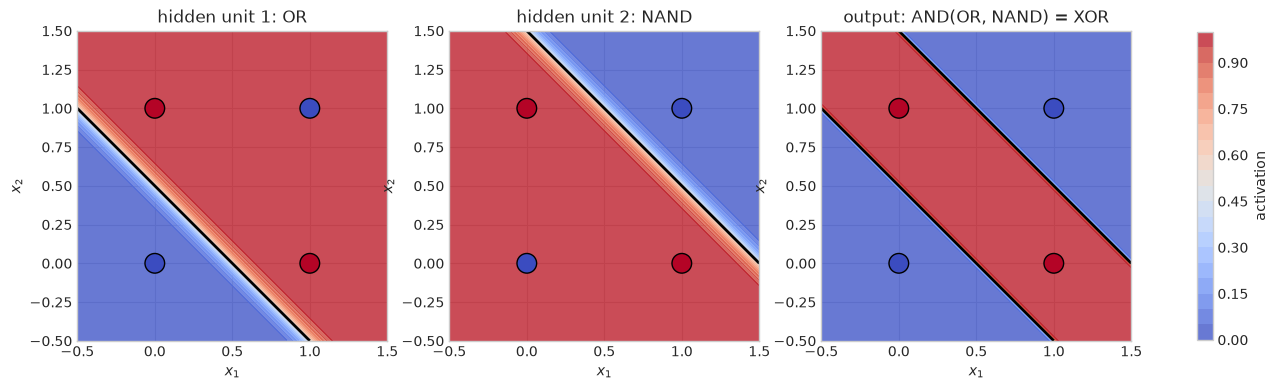

In [2]:
G1, G2 = np.meshgrid(np.linspace(-0.5, 1.5, 300), np.linspace(-0.5, 1.5, 300))
P = np.c_[G1.ravel(), G2.ravel()]
_, H, out = forward(P, [Theta1, Theta2])
panels = [(H[:, 0], "hidden unit 1: OR"), (H[:, 1], "hidden unit 2: NAND"), (out[:, 0], "output: AND(OR, NAND) = XOR")]

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, (vals, title) in zip(axes, panels, strict=True):
    im = ax.contourf(G1, G2, vals.reshape(G1.shape), levels=20, cmap="coolwarm", alpha=0.8)
    ax.contour(G1, G2, vals.reshape(G1.shape), levels=[0.5], colors="k", linewidths=2)
    ax.scatter(X[:, 0], X[:, 1], c=[0, 1, 1, 0], cmap="coolwarm", edgecolors="k", s=200, vmin=0, vmax=1)
    ax.set(title=title, xlabel="$x_1$", ylabel="$x_2$", aspect="equal")
fig.colorbar(im, ax=axes, shrink=0.8, label="activation")
plt.show()

### A random network: learned features are just nonlinear functions

With random weights, a 2-8-8-1 network already produces a curved, non-trivial response surface. Training (backpropagation + gradient descent) is what shapes these surfaces to fit the data.

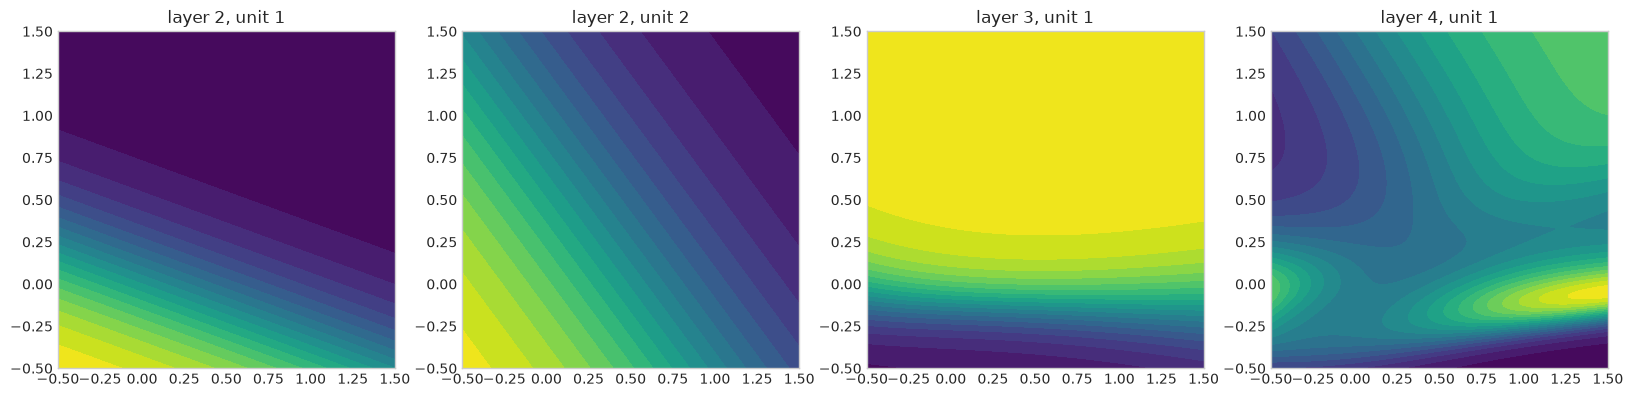

shapes: [(90000, 2), (90000, 8), (90000, 8), (90000, 1)] | weights: [(3, 8), (9, 8), (9, 1)]


In [3]:
rng = np.random.default_rng(7)
sizes = [2, 8, 8, 1]
thetas = [rng.normal(scale=3.0, size=(a + 1, b)) for a, b in zip(sizes[:-1], sizes[1:], strict=True)]
acts = forward(P, thetas)

fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
for ax, (layer, unit) in zip(axes, [(1, 0), (1, 1), (2, 0), (3, 0)], strict=True):
    ax.contourf(G1, G2, acts[layer][:, unit].reshape(G1.shape), levels=20, cmap="viridis")
    ax.set(title=f"layer {layer + 1}, unit {unit + 1}", aspect="equal")
plt.show()
print("shapes:", [a.shape for a in acts], "| weights:", [t.shape for t in thetas])

## Summary

- Each node is a logistic regression on the previous layer: $a^{(l+1)} = S([1, a^{(l)}]\Theta^{(l)})$.
- Add a bias node to every non-output layer.
- A hidden layer lets the network represent non-linearly-separable functions such as XOR.
- **Next**: the cost function (multi-output cross-entropy) and **backpropagation** to learn $\Theta$ from data (book ch08, see roadmap).